In [1]:
import os

from denovo_utils.data import Run
from denovo_utils.parsers import DenovoEngineConverter
from denovo_utils.io.read import load_psmlist

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from denovo_utils.analysis.metrics import load_seq_score_dicts
from denovo_utils.analysis.metrics import get_match_score_table, get_prc_curve

from psm_utils import Peptidoform
from tqdm import tqdm
from peak_pack.utils import calculate_ppm

from denovo_utils.analysis.metrics import (
    get_refinement_error_tables,
    plot_refinement_error_table,
    plot_precision_recall_refinement
)

import pandas as pd

from pathlib import Path

from denovo_utils.io.read import read_partitions_features, read_partitions_psmlist
from denovo_utils.io.save import save_psmlist

from itertools import chain

from glob import glob

from denovo_utils.io.read import load_pickle


2026-09-09 15:52:24.188032: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


In [45]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

In [2]:
denovo_names = denovo_engines = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'InstaNovo',
    'NovoB',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

In [3]:
import pickle
with open('runs_PXD028735_QExactive_modcleanup.pkl', 'rb') as f:
    runs = pickle.load(f)

In [ ]:
from denovo_utils.analysis.error_types import build_comparison_table

# Creation
comparison_tables = {}

for denovo_name, run in runs.items():
    comparison_tables[denovo_name] = build_comparison_table(
        run=run
    )

# Writing
# with open('comparison_tables_PXD028735_modcleanup.pkl', 'wb') as f:
#     pickle.dump(comparison_tables, f)

Calculating sequence distance for de novo PSMs: 100%|██████████| 49588/49588 [02:40<00:00, 309.35it/s]


In [8]:
# Reading
with open('comparison_tables_PXD028735_modcleanup.pkl', 'rb') as f:
    comparison_tables = pickle.load(f)

Concat the comparison tables together into a long dataframe

In [9]:
df = []

for run_name, table in comparison_tables.items():
    table['run']=run_name
    df.append(table)

df = pd.concat(df, ignore_index=True)

# 1. Levenshtein

necessary functions below:

In [62]:
import numpy as np
from denovo_utils.analysis.error_types import mass_difference
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

def add_swap_to_dict(d, swap, sc, swap_dicts=None, ordering_matters=False):
    aas_1 = sc._peptidoform_to_lstring(swap[0], mapper=sc.mod_mapper_reverse)
    aas_2 = sc._peptidoform_to_lstring(swap[1], mapper=sc.mod_mapper_reverse)
    if not ordering_matters:

        aas_1 = ''
        aas_2 = ''
        # Create new tags but in the same order.
        # This way, the set is always the same
        # The ordering is alphabetic on amino acids.
        for aa_1 in sorted(swap_dicts[0].keys(), key=lambda s: (s.isupper(), s.lower())):
            aas_1 += aa_1*swap_dicts[0][aa_1]
        for aa_2 in sorted(swap_dicts[1].keys(), key=lambda s: (s.isupper(), s.lower())):
            aas_2 += aa_2*swap_dicts[1][aa_2]

        aas_1 = sc._peptidoform_to_lstring(aas_1, mapper=sc.mod_mapper_reverse)
        aas_2 = sc._peptidoform_to_lstring(aas_2, mapper=sc.mod_mapper_reverse)

    set_swap = ' <-> '.join(set([aas_1, aas_2]))
    
    if set_swap in d.keys():
        d[set_swap] += 1
    else:
        d[set_swap] = 1

def check_same_aas(swap):
    dict_1 = {}
    dict_2 = {}

    for aa in swap[0]:
        if aa in dict_1.keys():
            dict_1[aa] += 1
        else:
            dict_1[aa] = 1
    
    for aa in swap[1]:
        if aa in dict_2.keys():
            dict_2[aa] += 1
        else:
            dict_2[aa] = 1
    return (dict_1, dict_2), dict_1 == dict_2


def get_variants(df, annotations_col, n_sites_col, comparison_col):

    variations = {
        'reordering': {},
        'isobaric_alternative': {},
        'alternative': {}
    }
    indices = {
        'reordering': [],
        'isobaric_alternative': [],
        'alternative': []
    }
    md_alternatives = []

    for i, (annotations, sites, sc) in df[[annotations_col, n_sites_col, comparison_col]].iterrows():

        if sites == 1:
            # First index = select tag list
            # Second index = select first tag
            swap_ = annotations['forward'][0][0].split(' -> ')
            swap = swap_.copy()
            swap[0] = sc._peptidoform_to_lstring(swap[0], mapper=sc.mod_mapper)
            swap[1] = sc._peptidoform_to_lstring(swap[1], mapper=sc.mod_mapper)

            (dict_1, dict_2), same_composition = check_same_aas(swap)

            md = np.round(abs(mass_difference(
                s1=swap_[0],
                s2=swap_[1]
            )), decimals=3)

            # Reordering:
            if same_composition:
                add_swap_to_dict(variations['reordering'], swap, ordering_matters=True, sc=sc)
                indices['reordering'].append(i)

            # Isobaric
            elif md<.01:
                add_swap_to_dict(
                    variations['isobaric_alternative'],
                    swap,
                    swap_dicts=[dict_1,dict_2],
                    ordering_matters=False,
                    sc=sc
                )
                indices['isobaric_alternative'].append(i)

            else:
                add_swap_to_dict(variations['alternative'], swap, ordering_matters=True, sc=sc)
                md_alternatives.append(md)
                indices['alternative'].append(i)
   
    return variations, md_alternatives, indices

def get_variants_per_model(
        df,
        model_names,
        comparison_col,
        model_col,
        annotations_col,
        n_sites_col
        ):
    variant_tables, md_tables, indices = {}, {}, {}
    for model in model_names:
        df_selection = df[df[model_col]==model]
        variants, mds, indices_model = get_variants(
            df=df_selection,
            annotations_col=annotations_col,
            n_sites_col=n_sites_col,
            comparison_col=comparison_col
        )
        variant_tables[model] = variants
        md_tables[model] = mds
        indices[model] = indices_model
    return variant_tables, md_tables, indices

def select_top_n_variants(variant_count_table, top_n, full_count_dict, aggregated=False):
    variant_count_table_count_dict = variant_count_table.set_index('variant').sum().to_dict()

    variant_count_table_melted = variant_count_table.melt(
        id_vars='variant'
    )
    variant_count_table_melted['percentage_of_all'] = variant_count_table_melted.apply(
        lambda x: x['value']/full_count_dict[x['variable']],
        axis=1
    )
    variant_count_table_melted['percentage'] = variant_count_table_melted.apply(
        lambda x: x['value']/(variant_count_table_count_dict[x['variable']]+1) *100 ,
        axis=1
    )
    variant_count_table_melted = variant_count_table_melted.sort_values('percentage', ascending=False)

    if aggregated:
        most_common_variants = (variant_count_table_melted
                                .groupby('variant')
                                .percentage
                                .median()
                                .sort_values(ascending=False)[:top_n]
                                ).index.tolist()
    else:
        most_common_variants = (variant_count_table_melted
                                .sort_values('percentage', ascending=False)
                                .drop_duplicates('variant')['variant']
                                .tolist()[:top_n])

    print('Plotted percentage: {:.3f}%'.format(
        variant_count_table_melted[
            variant_count_table_melted['variant'].isin(most_common_variants)
        ].groupby('variable').sum()['percentage'].mean()
    ))
    return variant_count_table_melted, most_common_variants

def plot_variants_as_heatmap(selection_df, most_common_variants, name=None):

    heatmap_data = selection_df[
        selection_df['variant'].isin(most_common_variants)
    ].pivot(
        index='variant',
        columns='variable',
        values='percentage'
    ).loc[most_common_variants]

    mask = heatmap_data.isnull()

    cmap = sns.cm.rocket
    cmap.set_bad(color='lightgrey')

    plt.figure(figsize=(4,8))
    sns.heatmap(
        heatmap_data,
        linewidths=0.5,
        cmap=cmap,
        mask=mask
    )
    plt.xlabel('Model')
    plt.ylabel('Gold-standard <-> De novo')
    plt.show(name)          # was plt.show()

    return heatmap_data     # exactly what was plotted
    

def heatmap_variants_with_plotly(selection_df, most_common_variants):
    # Plot with plotly
    heatmap_data = selection_df[
        selection_df['variant'].isin(most_common_variants)
    ].pivot(
        index='variant',
        columns='variable',
        values='percentage'
    ).loc[most_common_variants]

    fig = px.imshow(
        heatmap_data,
        color_continuous_scale='RdBu',  # You can change this to any Plotly scale
        aspect='auto',
        labels=dict(x="Variable", y="Variant", color="Percentage"),
    )

    # Set grey for missing values
    fig.update_traces(
        zmin=0,  # or your data's minimum
        zmax=100,  # or your data's maximum
        colorbar=dict(title="Percentage"),
        hovertemplate='Variant: %{y}<br>Variable: %{x}<br>Percentage: %{z:.2f}<extra></extra>'
    )

    fig.update_layout(
        title="Isobaric Transposition Heatmap",
        xaxis_title="Variable",
        yaxis_title="Variant",
        xaxis_showgrid=False,
        yaxis_showgrid=False,
        plot_bgcolor='white'
    )

    # Set color for missing values (NaNs)
    fig.update_traces(colorscale='RdBu', showscale=True, zauto=False)
    fig.update_coloraxes(colorbar_title='Percentage', cmin=0, cmax=100, cauto=False)

    fig.show()


def show_distance_from_terminus(df):
    distance_from_terminus = df.groupby(
        ['model', 'terminus']
    ).distance_from_terminus.value_counts(normalize=True)
    distance_from_terminus.name = 'percentage'

    distance_from_terminus = distance_from_terminus.reset_index()

    distance_from_n = distance_from_terminus[
        distance_from_terminus['terminus']=='N'
    ]
    distance_from_c = distance_from_terminus[
        distance_from_terminus['terminus']=='C'
    ]

    plt.figure(figsize=(6,4))
    sns.heatmap(
        distance_from_c.pivot(
            index='distance_from_terminus',
            columns='model',
            values='percentage'
        ).fillna(0).round(decimals=2),
        annot=True,
        vmin=0,
        vmax=1,
        cmap='coolwarm'
    )
    plt.xlabel('Model')
    plt.ylabel('Distance from C-terminus')

    plt.figure(figsize=(6,4))
    sns.heatmap(
        distance_from_n.pivot(
            index='distance_from_terminus',
            columns='model',
            values='percentage'
        ).fillna(0).round(decimals=2),
        annot=True,
        vmin=0,
        vmax=1,
        cmap='coolwarm'
    )
    plt.xlabel('Model')
    plt.ylabel('Distance from N-terminus')

    table = df.groupby('model').terminus.value_counts(normalize=True)
    table.name = 'percentage'
    return table

In [11]:
def get_error_types(df, denovo_engines):
    count_dict = df.groupby('model').spectrum_id.count().to_dict()
    variants = {'tables': {}, 'indices': {}, 'mds': {}}

    # Single amino acid variants
    single_amino_acid_switches = df[
        df.levenshtein==1
    ]
    single_amino_acid_switches_count = single_amino_acid_switches.groupby('model').count()['spectrum_id'] 
    print('Single variants')
    single_variants, single_mds, indices = get_variants_per_model(
        df=single_amino_acid_switches,
        comparison_col='comparison_closest',
        annotations_col='annotations_merged',
        n_sites_col='n_sites_merged',
        model_col='model',
        model_names=denovo_engines
    )
    variants['indices']['SAAV'] = indices
    variants['mds']['SAAV'] = single_mds
    single_variant_table = pd.concat(
        [pd.DataFrame(
            {model_name: v['alternative'] for model_name, v in single_variants.items()}
        ),
        pd.DataFrame(
            {model_name: v['isobaric_alternative'] for model_name,v in single_variants.items()}
        )]
    ).reset_index(names='variant')
    single_variants_melted, most_common_saav = select_top_n_variants(
        variant_count_table=single_variant_table,
        top_n=20,
        full_count_dict=count_dict,
        aggregated=False
    )

    # Store SAAVs
    variants['SAAV'] = {
        'single_variants_melted': single_variants_melted,
        'most_common_saav': most_common_saav
    }

    print('Transpositions')
    # Transpositions
    transpositions = df[
        (df['n_sites_merged']==1) &
        (df['levenshtein'] != 1) &
        (df['damerau-levenshtein'] < 5)
    ]
    transpositions_count = transpositions.groupby('model').count()['spectrum_id']
    transposition_variants, transposition_mds, indices = get_variants_per_model(
        df=transpositions,
        comparison_col='comparison_closest',
        model_col='model',
        annotations_col='annotations_merged',
        n_sites_col='n_sites_merged',
        model_names=denovo_engines
    )
    variants['indices']['transpositions'] = indices
    transposition_alternative = pd.DataFrame(
        {model_name: v['alternative'] for model_name,v in transposition_variants.items()}
    ).reset_index(names='variant')
    transposition_isobaric = pd.DataFrame(
        {model_name: v['isobaric_alternative'] for model_name,v in transposition_variants.items()}
    ).reset_index(names='variant')
    transposition_reordering =pd.DataFrame(
        {model_name: v['reordering'] for model_name,v in transposition_variants.items()}
    ).reset_index(names='variant')
    
    variants['mds']['transpositions'] = transposition_mds

    transposition_table = pd.concat(
        [transposition_alternative, transposition_isobaric, transposition_reordering]
    )
    variants['tables'] = {
        'transposition_alternative':transposition_alternative,
        'transposition_isobaric':transposition_isobaric,
        'transposition_reordering':transposition_reordering,
        'transposition_table': transposition_table
    }

    print('Reorderings')
    transposition_reordering_selection, most_common_transpositions = select_top_n_variants(
        variant_count_table=transposition_reordering,
        top_n=20,
        full_count_dict=count_dict,
        aggregated=False
    )
    variants['Reorderings'] = {
        'transposition_reordering_selection': transposition_reordering_selection,
        'most_common_transpositions': most_common_transpositions
    }

    print('Isobaric')
    transposition_isobaric_selection, most_common_transpositions = select_top_n_variants(
        variant_count_table=transposition_isobaric,
        top_n=20,
        full_count_dict=count_dict,
        aggregated=False
    )
    variants['isobaric'] = {
        'transposition_isobaric_selection': transposition_isobaric_selection,
        'most_common_transpositions': most_common_transpositions
    }

    print('Alternative')
    transposition_alternative_selection, most_common_transpositions = select_top_n_variants(
        variant_count_table=transposition_alternative,
        top_n=20,
        full_count_dict=count_dict,
        aggregated=False
    )
    variants['alternative'] = {
        'transposition_alternative_selection': transposition_alternative_selection,
        'most_common_transpositions': most_common_transpositions
    }
    return variants

In [12]:
error_type = get_error_types(
    df=df,
    denovo_engines=df['model'].unique()
)

Single variants
Plotted percentage: 86.310%
Transpositions
Reorderings
Plotted percentage: 34.187%
Isobaric
Plotted percentage: 39.914%
Alternative
Plotted percentage: 3.777%


In [13]:
count_dict = df.groupby('model').spectrum_id.count().to_dict()

In [10]:
count_dict

{'AdaNovo': 129197,
 'Casanovo4.2.0': 116044,
 'ContraNovo': 50761,
 'InstaNovo': 113755,
 'NovoB': 111476,
 'PepNet': 124604,
 'pi-HelixNovo': 128334,
 'pi-PrimeNovo': 94682}

---

### Correlation plot with occurence of diamino acids

In [15]:
occurences_variants = error_type['tables']['transposition_table'].set_index('variant').T.sum().sort_values(ascending=False)
variants = occurences_variants.index.tolist()
variant_dict = {var: 0 for var in variants}

In [16]:
occurences_variants_casanovo = error_type['tables']['transposition_table'].set_index('variant')['Casanovo4.2.0']

In [17]:
transposition_indices = list(set(chain(*[
    list(chain(*[
        k for k in i.values()
    ])) for i in error_type['indices']['transpositions'].values()
])))

In [18]:
spectra_transpositions = df.loc[transposition_indices][['spectrum_id', 'run']].drop_duplicates()

In [19]:
for run in runs.values():
    for spectrum in tqdm(run.spectra.values()):
        peptidoform = [psm.peptidoform.proforma.replace('UNIMOD', 'u') for psm in spectrum.psm_gold_standard if psm.rank == 1][0]
        for var in variant_dict.keys():
            var1, var2 = var.replace('UNIMOD', 'u').split(' <-> ')
            if var1 in peptidoform or var2 in peptidoform:
                variant_dict[var] += 1

100%|██████████| 49588/49588 [24:08<00:00, 34.24it/s]


In [20]:
occ_err = occurences_variants.reset_index().rename(columns={0:'Error occurence'}).merge(
    pd.Series(variant_dict).reset_index().rename(columns={0:'Occurence in gold standard', 'index': 'variant'})
)

In [21]:
occ_err_casanovo = occurences_variants_casanovo.reset_index().rename(columns={0:'Error occurence'}).merge(
    pd.Series(variant_dict).reset_index().rename(columns={0:'Occurence in gold standard', 'index': 'variant'})
)

In [127]:
occ_err_casanovo

,variant,Casanovo4.2.0,Occurence in gold standard
0,GQ <-> AN[UNIMOD:7],15.0,8573
1,NAN[UNIMOD:7] <-> GQN,1.0,343
2,AGAGT <-> GPNA,NaN,49
3,GN[UNIMOD:7]GE <-> N[UNIMOD:7]GGGA,NaN,8
4,N[UNIMOD:7]DI <-> NEV,NaN,651
...,...,...,...
78816,QN[UNIMOD:7] <-> N[UNIMOD:7]Q,NaN,533
78817,IAPIT <-> PITIA,NaN,1
78818,EQDS <-> SQDE,NaN,49
78819,NDA <-> ADN,NaN,1283


<Axes: xlabel='Error occurence', ylabel='Occurence in gold standard'>

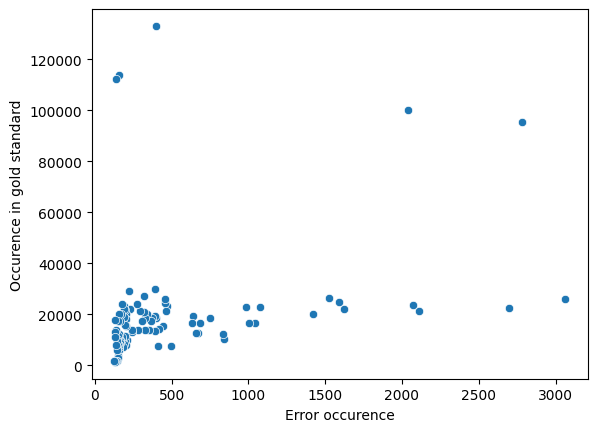

In [83]:
sns.scatterplot(
    occ_err.head(100),
    x='Error occurence',
    y='Occurence in gold standard'
)

In [22]:
occ_err.loc[
        occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
    ].sort_values('Occurence in gold standard', ascending=False).head(100)

,variant,Error occurence,Occurence in gold standard
32,AE <-> EA,391.0,29788
52,VE <-> EV,223.0,28988
40,VA <-> AV,318.0,26975
25,DE <-> ED,455.0,26089
51,AG <-> GA,225.0,24527
...,...,...,...
130,HG <-> GH,93.0,8935
70,YS <-> SY,163.0,8756
131,KI <-> IK,92.0,8620
123,FQ <-> QF,99.0,8380


In [23]:

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

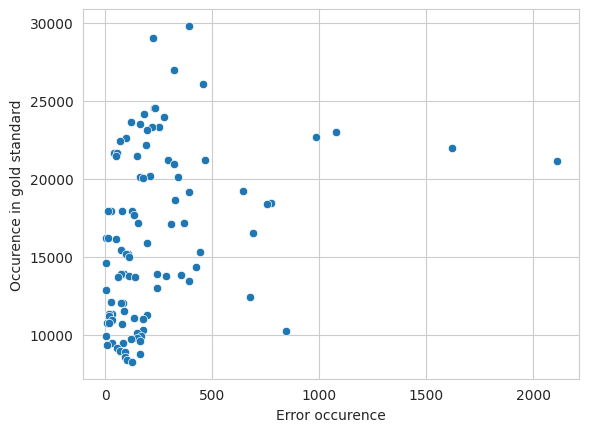

In [32]:
sns.scatterplot(
    occ_err.loc[
        occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
    ].sort_values('Occurence in gold standard', ascending=False).head(100),
    x='Error occurence',
    y='Occurence in gold standard'
)
plt.show('Suppl_ErrorOccurence')

# Source data out
occ_err.loc[
        occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
    ].sort_values('Occurence in gold standard', ascending=False).to_excel(
        'source_data/Supplementary_ErrorOccurence.xlsx', engine='openpyxl'
    )

In [27]:
from scipy.stats import spearmanr, pearsonr

In [110]:
sample_set = occ_err.loc[
    occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
].head(100)
spearmanr(
    a=sample_set['Error occurence'].tolist(),
    b=sample_set['Occurence in gold standard'].tolist()
)

SignificanceResult(statistic=0.5646099715770749, pvalue=9.453123929440845e-10)

In [107]:
sample_set = occ_err.loc[
    occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
]
spearmanr(
    a=sample_set['Error occurence'].tolist(),
    b=sample_set['Occurence in gold standard'].tolist()
)

SignificanceResult(statistic=0.49841514699653316, pvalue=0.0)

In [108]:
sample_set = occ_err
spearmanr(
    a=sample_set['Error occurence'].tolist(),
    b=sample_set['Occurence in gold standard'].tolist()
)

SignificanceResult(statistic=0.24151804298251292, pvalue=0.0)

In [99]:
occ_err.loc[
        occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
    ].sort_values('Occurence in gold standard', ascending=False).head(50)

,variant,Error occurence,Occurence in gold standard
33,EA <-> AE,391.0,29788
50,EV <-> VE,223.0,28988
42,AV <-> VA,318.0,26975
26,DE <-> ED,455.0,26089
25,AG <-> GA,457.0,24527
65,GE <-> EG,178.0,24131
46,VG <-> GV,272.0,23936
192,VD <-> DV,67.0,23638
238,DV <-> VD,53.0,23638
128,DA <-> AD,94.0,23485


In [94]:
occ_err.loc[
        occ_err['variant'].apply(lambda x: set(x.split(' <-> ')[0])==set(x.split(' <-> ')[1]))
    ]

,variant,Error occurence,Occurence in gold standard
3,VI <-> IV,2108.0,21167
6,AI <-> IA,1621.0,21940
10,SG <-> GS,1075.0,22984
13,EI <-> IE,986.0,22647
14,FI <-> IF,842.0,10241
...,...,...,...
75760,APIYDIAAHED <-> IPIYDIAAHE,1.0,0
75883,TAPVIESPYGETIIPEEDAPE <-> GAPVIESPYGETISPEDAPES,1.0,2
76245,VGG <-> GV,1.0,14607
76463,NIGEIIEIAGC[UNIMOD:4]D <-> DEGEIIEIAGC[UNIMOD:4]E,1.0,0


---

In [28]:
def plot_levenshtein_pattern(comparison_df, title):
    plt.figure(figsize=(12,3))
    levenshtein = comparison_df[
            comparison_df.n_sites_merged==1
        ].pivot(
        index=['run', 'spectrum_id'],
        columns='model',
        values='levenshtein'
    )
    levenshtein_melted = levenshtein.melt()
    normalized_df = (
        levenshtein_melted[
            (levenshtein_melted['value'].notna()) &
            (levenshtein_melted['value'] < 20)
        ]
        .groupby(['model', 'value'])
        .size()
        .rename('count')
        .reset_index()
    )

    normalized_df['percentage'] = (
        normalized_df['count'] /
        normalized_df.groupby('model')['count'].transform('sum')
        * 100
    )

    normalized_df = normalized_df.drop(columns='count')

    sns.barplot(
        normalized_df,
        x='value',
        y='percentage',
        hue='model',
    )
    plt.xlabel('Levenshtein distance')
    plt.title(title)

    plt.figure(figsize=(12,3))
    levenshtein = comparison_df[
            comparison_df.n_sites_merged==1
        ].pivot(
        index=['run', 'spectrum_id'],
        columns='model',
        values='damerau-levenshtein'
    )
    levenshtein_melted = levenshtein.melt()
    filtered = levenshtein_melted[
        (levenshtein_melted['value'].notna()) &
        (levenshtein_melted['value'] < 20)
    ]

    normalized_df = (
        filtered
        .groupby(['model', 'value'])
        .size()
        .rename('count')
        .reset_index()
    )

    normalized_df['percentage'] = (
        normalized_df['count']
        .div(normalized_df.groupby('model')['count'].transform('sum'))
        .mul(100)
    )

    normalized_df = normalized_df[['model', 'value', 'percentage']]


    sns.barplot(
        normalized_df,
        x='value',
        y='percentage',
        hue='model',
    )
    plt.xlabel('Damerau-Levenshtein distance')
    plt.title(title)

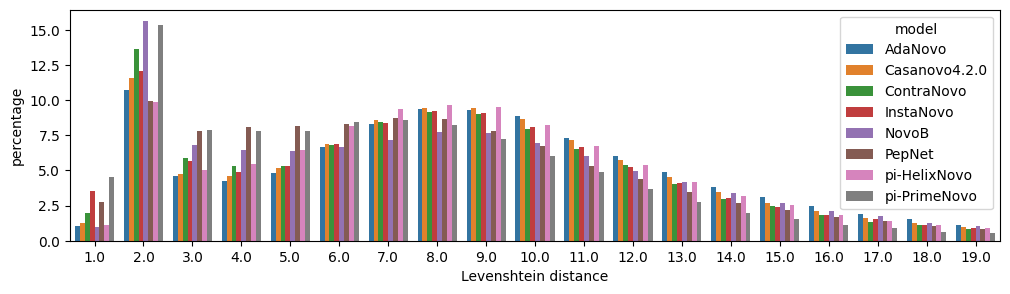

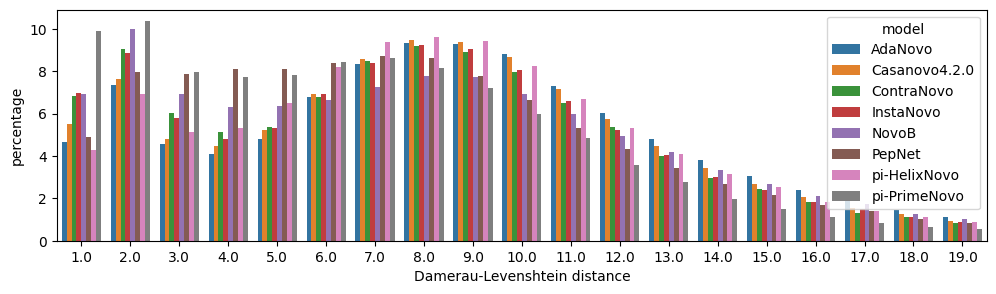

In [12]:
plot_levenshtein_pattern(
    comparison_df=df,
    title=''
)

In [34]:
def get_ambiguity(collection):
    for tag in collection['forward']:
        if 'ambiguous' not in tag.keys():
            return None
        if not tag['ambiguous']:
            return 'Not ambiguous'
    
    return 'ambiguous'


def get_min_distance(row):
    min_c = 100
    min_n = 100

    min_c_2 = 100
    min_n_2 = 100

    for tag in row['collection_merged']['forward']:
        if 'n_term' not in tag.keys():
            return None, None

        # if row['psm_denovo'].peptidoform.properties['n_term'] is not None:
        #     tag['c_term'] += len(row['psm_denovo'].peptidoform.properties['n_term'])

        min_c = min(min_c, tag['c_term'])
        min_n = min(min_n, tag['n_term'])

    # for tag in row['collection_merged']['backward']:
    #     if 'n_term' not in tag.keys():
    #         return None, None

    #     # if row['psm_gt'].peptidoform.properties['n_term'] is not None:
    #     #     tag['c_term'] += len(row['psm_gt'].peptidoform.properties['n_term'])

    #     min_c_2 = min(min_c_2, tag['c_term'])
    #     min_n_2 = min(min_n_2, tag['n_term'])

    # min_c = max(min_c_2, min_c)

    if min_n < min_c:
        return min_n, 'N'
    return min_c, 'C'

df['ambiguous'] = df.apply(lambda x: get_ambiguity(x['collection_merged']), axis=1)
df['from_terminus'] = df.progress_apply(get_min_distance, axis=1)
df['terminus'] = df.apply(lambda x: x['from_terminus'][1], axis=1)
df['distance_from_terminus'] = df.apply(lambda x: x['from_terminus'][0], axis=1)

100%|██████████| 868853/868853 [00:05<00:00, 150026.89it/s]


In [15]:
df['collection_merged'][0]['forward'][0]

{'target': 'GFSGED',
 'source': 'FSADAT',
 'indices': [0, 1, 2, 3, 4, 5],
 'annotation': 'partly',
 'n_term': 0,
 'c_term': 19,
 'ambiguous': False,
 'mass_difference': -0.03638550872005908}

In [36]:
def create_ambiguity_heatmap(df, annot=False, figsize_x=6, figsize_y=5):
    ambiguity_matrix = df[
        df.symmetric_x
    ].groupby(
        ['model', 'damerau-levenshtein']
    )['ambiguous'].value_counts(normalize=True)
    ambiguity_matrix.name = 'percentage'
    ambiguity_matrix = ambiguity_matrix.reset_index()
    ambiguity_matrix = ambiguity_matrix[ambiguity_matrix['ambiguous']=='ambiguous']
    plt.figure(figsize=(figsize_x,figsize_y))
    sns.heatmap(
        ambiguity_matrix.pivot(
            index='damerau-levenshtein',
            columns='model',
            values='percentage'
        ).fillna(0),
        annot=annot,
        vmax=1,
        vmin=0
    )
    return ambiguity_matrix

In [37]:
error_type['indices']['transpositions']['AdaNovo'].keys()

dict_keys(['reordering', 'isobaric_alternative', 'alternative'])

In [38]:
reordering_indices = list(chain(*[v['reordering'] for k, v in error_type['indices']['transpositions'].items()]))
isobaric_alternative_indices = list(chain(*[v['isobaric_alternative'] for k, v in error_type['indices']['transpositions'].items()]))
alternative_indices = list(chain(*[v['alternative'] for k, v in error_type['indices']['transpositions'].items()]))

In [39]:
reor_iso_indices = reordering_indices+isobaric_alternative_indices

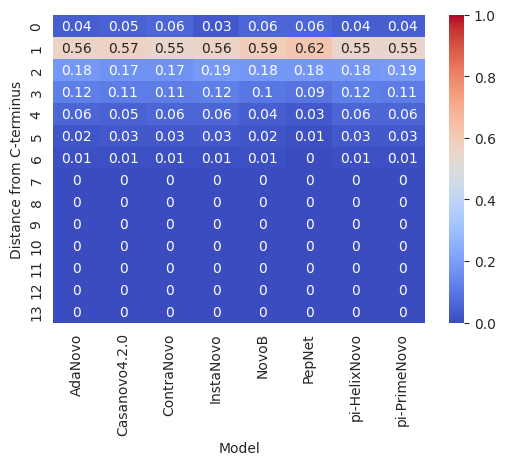

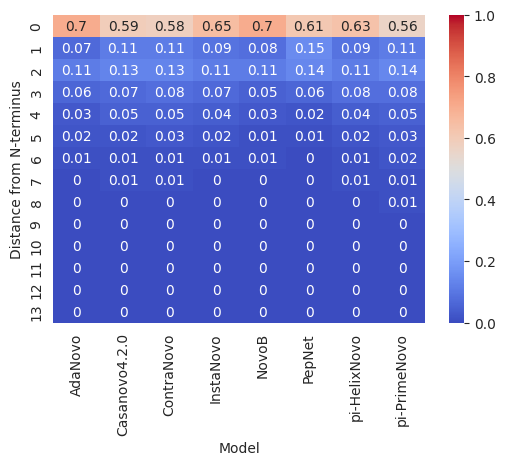

In [47]:
df_=df.loc[reor_iso_indices]
distance_from_terminus = df_.groupby(
    ['model', 'terminus']
).distance_from_terminus.value_counts(normalize=True)
distance_from_terminus.name = 'percentage'

distance_from_terminus = distance_from_terminus.reset_index()

distance_from_n = distance_from_terminus[
    distance_from_terminus['terminus']=='N'
]
distance_from_c = distance_from_terminus[
    distance_from_terminus['terminus']=='C'
]

plt.figure(figsize=(6,4))
sns.heatmap(
    distance_from_c.pivot(
        index='distance_from_terminus',
        columns='model',
        values='percentage'
    ).fillna(0).round(decimals=2),
    annot=True,
    vmin=0,
    vmax=1,
    cmap='coolwarm'
)
plt.xlabel('Model')
plt.ylabel('Distance from C-terminus')
plt.show('Suppl_distanceFromC')

plt.figure(figsize=(6,4))
sns.heatmap(
    distance_from_n.pivot(
        index='distance_from_terminus',
        columns='model',
        values='percentage'
    ).fillna(0).round(decimals=2),
    annot=True,
    vmin=0,
    vmax=1,
    cmap='coolwarm'
)
plt.xlabel('Model')
plt.ylabel('Distance from N-terminus')
plt.show('Suppl_distanceFromN')

table = df_.groupby('model').terminus.value_counts(normalize=True)
table.name = 'percentage'

In [ ]:
distance_from_c.pivot(
        index='distance_from_terminus',
        columns='model',
        values='percentage'
    ).fillna(0).round(decimals=2).to_excel('source_data/Source_Data_suppl_distancefromC.xlsx', engine='openpyxl')

distance_from_n.pivot(
        index='distance_from_terminus',
        columns='model',
        values='percentage'
    ).fillna(0).round(decimals=2).to_excel('source_data/Source_Data_suppl_distancefromN.xlsx', engine='openpyxl')

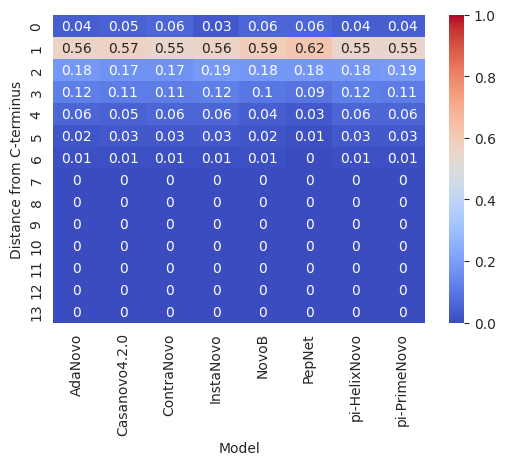

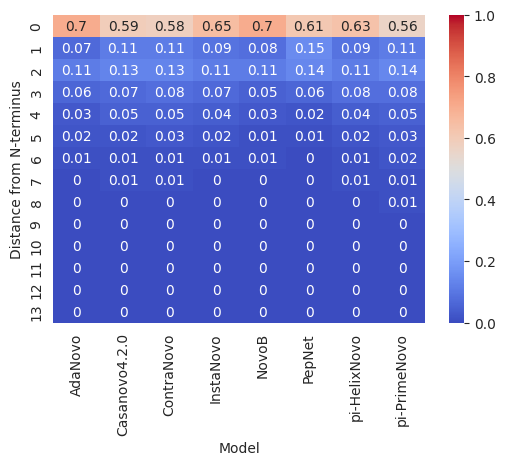

In [ ]:
# table = show_distance_from_terminus(
#     df.loc[reor_iso_indices]
# )

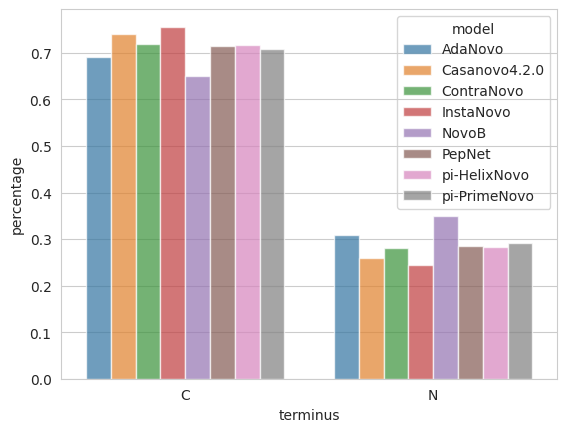

In [51]:
sns.barplot(
    table.reset_index(),
    x='terminus',
    hue='model',
    y='percentage',
    alpha=.7
)
plt.show('Suppl_Fig_terminusratio')

src = table.reset_index()
src.insert(0, "figure", "Supplementary Figure X")
src.to_excel("source_data/Source_Data_Terminus.xlsx", sheet_name="terminus", index=False)

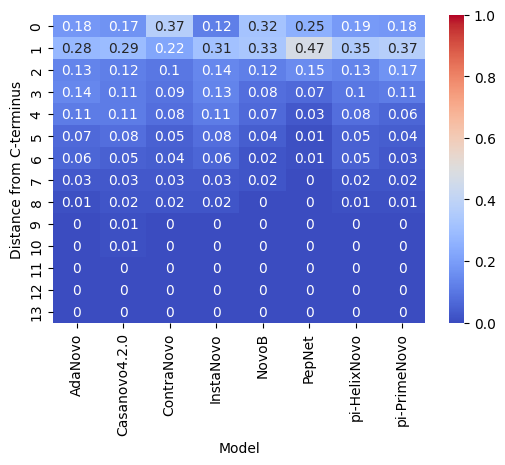

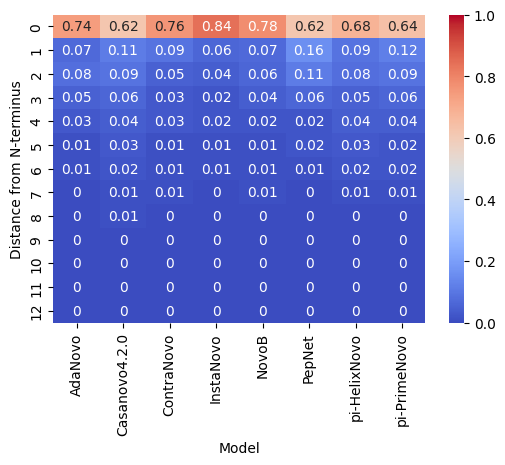

<Axes: xlabel='terminus', ylabel='percentage'>

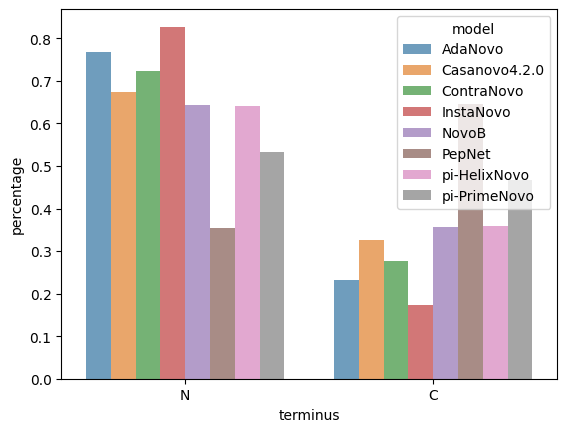

In [155]:
table = show_distance_from_terminus(
    df.loc[alternative_indices]
)
plt.show()

sns.barplot(
    table.reset_index(),
    x='terminus',
    hue='model',
    y='percentage',
    alpha=.7
)

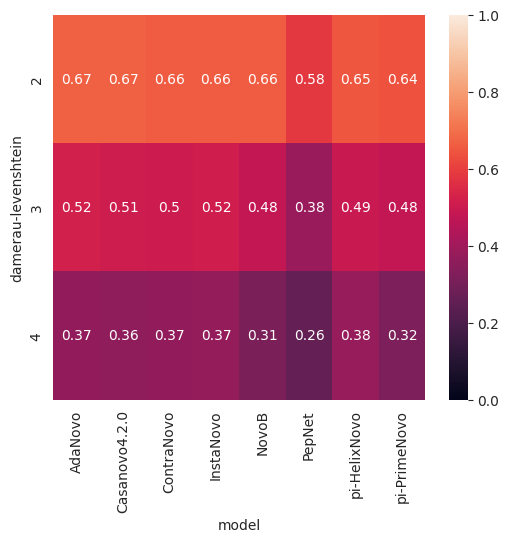

In [ ]:
df_ = df.loc[
    isobaric_alternative_indices
]
figsize_x, figsize_y = 6, 5
annot=True


ambiguity_matrix = df_[
    df_.symmetric_x
].groupby(
    ['model', 'damerau-levenshtein']
)['ambiguous'].value_counts(normalize=True)
ambiguity_matrix.name = 'percentage'
ambiguity_matrix = ambiguity_matrix.reset_index()
ambiguity_matrix = ambiguity_matrix[ambiguity_matrix['ambiguous']=='ambiguous']
plt.figure(figsize=(figsize_x,figsize_y))
sns.heatmap(
    ambiguity_matrix.pivot(
        index='damerau-levenshtein',
        columns='model',
        values='percentage'
    ).fillna(0),
    annot=annot,
    vmax=1,
    vmin=0
)
plt.show('Suppl_fig_isobaric_DLDist')

matrix = ambiguity_matrix.pivot(index='damerau-levenshtein', columns='model',
                                values='percentage').fillna(0)
matrix.to_excel("source_data/Source_Data_Suppl_IsobaricDL.xlsx", sheet_name="Figure X")

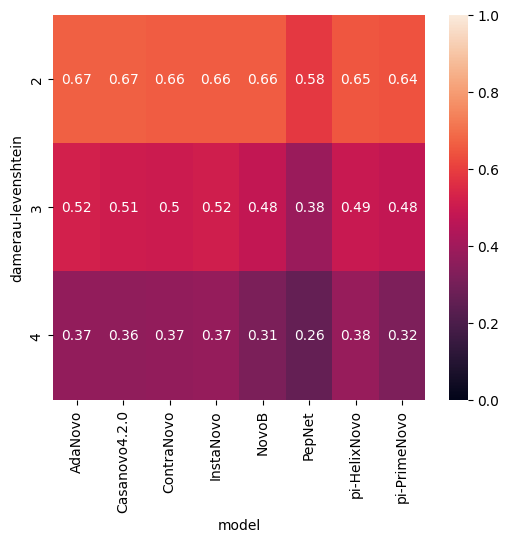

In [ ]:
# _ = create_ambiguity_heatmap(
#     df.loc[
#     isobaric_alternative_indices
# ],
# annot=True
# )

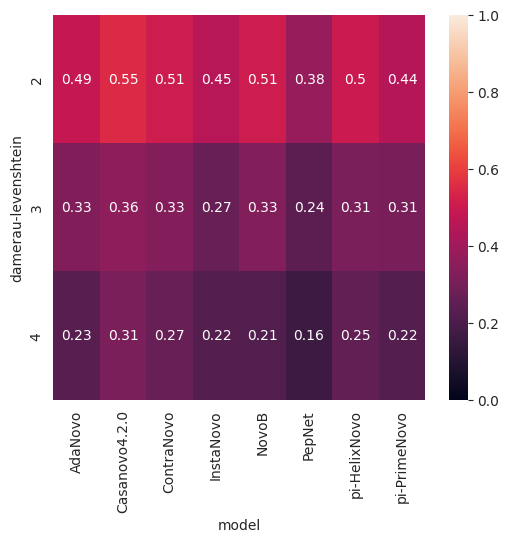

In [53]:
df_ = df.loc[
    alternative_indices
]
figsize_x, figsize_y = 6, 5
annot=True


ambiguity_matrix = df_[
    df_.symmetric_x
].groupby(
    ['model', 'damerau-levenshtein']
)['ambiguous'].value_counts(normalize=True)
ambiguity_matrix.name = 'percentage'
ambiguity_matrix = ambiguity_matrix.reset_index()
ambiguity_matrix = ambiguity_matrix[ambiguity_matrix['ambiguous']=='ambiguous']
plt.figure(figsize=(figsize_x,figsize_y))
sns.heatmap(
    ambiguity_matrix.pivot(
        index='damerau-levenshtein',
        columns='model',
        values='percentage'
    ).fillna(0),
    annot=annot,
    vmax=1,
    vmin=0
)
plt.show('Suppl_fig_nonisobaric_DLDist')

matrix = ambiguity_matrix.pivot(index='damerau-levenshtein', columns='model',
                                values='percentage').fillna(0)
matrix.to_excel("source_data/Source_Data_Suppl_NonIsobaricDL.xlsx", sheet_name="Figure X")

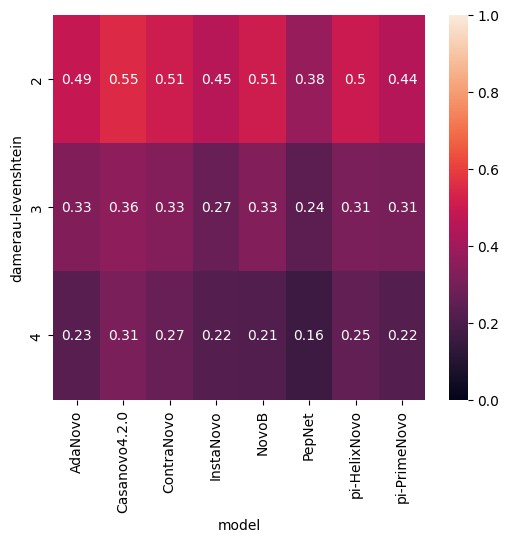

In [ ]:
# _ = create_ambiguity_heatmap(
#     df.loc[
#     alternative_indices
# ],
# annot=True
# )

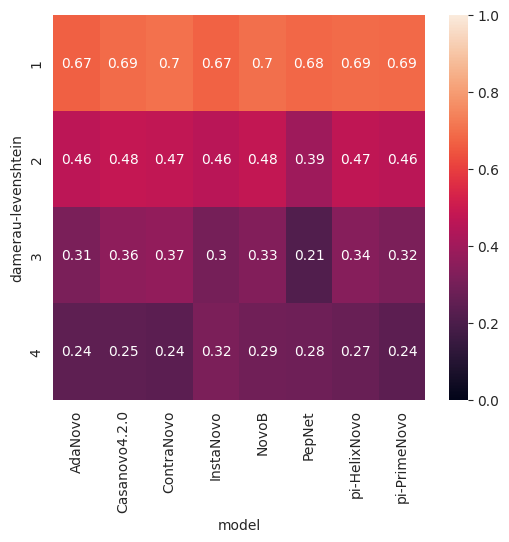

In [54]:
df_ = df.loc[
    reordering_indices
]
figsize_x, figsize_y = 6, 5
annot=True


ambiguity_matrix = df_[
    df_.symmetric_x
].groupby(
    ['model', 'damerau-levenshtein']
)['ambiguous'].value_counts(normalize=True)
ambiguity_matrix.name = 'percentage'
ambiguity_matrix = ambiguity_matrix.reset_index()
ambiguity_matrix = ambiguity_matrix[ambiguity_matrix['ambiguous']=='ambiguous']
plt.figure(figsize=(figsize_x,figsize_y))
sns.heatmap(
    ambiguity_matrix.pivot(
        index='damerau-levenshtein',
        columns='model',
        values='percentage'
    ).fillna(0),
    annot=annot,
    vmax=1,
    vmin=0
)
plt.show('Suppl_fig_Permutation_DLDist')

matrix = ambiguity_matrix.pivot(index='damerau-levenshtein', columns='model',
                                values='percentage').fillna(0)
matrix.to_excel("source_data/Source_Data_Suppl_PermutationDL.xlsx", sheet_name="Figure X")

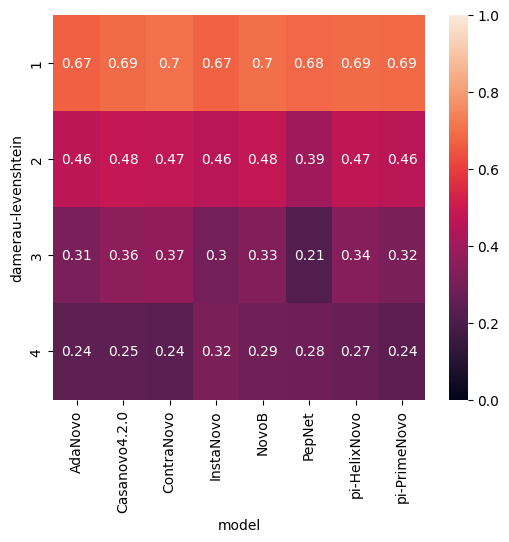

In [ ]:
# _ = create_ambiguity_heatmap(
#     df.loc[
#     reordering_indices
# ],
# annot=True
# )

In [133]:
_[_['damerau-levenshtein']==1]['percentage'].mean()

0.6850879664298669

,model,damerau-levenshtein,ambiguous,percentage
0,AdaNovo,1,ambiguous,0.699316
2,AdaNovo,2,ambiguous,0.561632
5,AdaNovo,3,ambiguous,0.410562
7,AdaNovo,4,ambiguous,0.287585
9,AdaNovo,5,ambiguous,0.278831
...,...,...,...,...
411,pi-PrimeNovo,20,ambiguous,0.011673
413,pi-PrimeNovo,21,ambiguous,0.020202
415,pi-PrimeNovo,22,ambiguous,0.015038
417,pi-PrimeNovo,23,ambiguous,0.013333


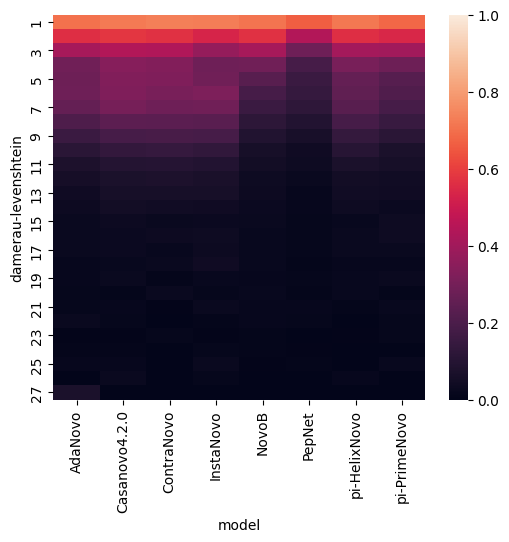

In [18]:
create_ambiguity_heatmap(df)

In [55]:
table_pct = {}

In [56]:
single_amino_acid_switches = df[
    df.levenshtein==1
]
single_amino_acid_switches_count = single_amino_acid_switches.groupby('model').count()['spectrum_id'] 

print('% of spectra with levenshtein distance == 1')

table_pct['SAAV'] = (
    single_amino_acid_switches_count
    / df.groupby('model').count()['spectrum_id']
)*100
print(table_pct['SAAV'])

print('\nAverage %')

print((
    (single_amino_acid_switches_count / 
    df.groupby('model').count()['spectrum_id']).mean()
)*100)

% of spectra with levenshtein distance == 1
model
AdaNovo          0.865345
Casanovo4.2.0    1.051325
ContraNovo       1.611473
InstaNovo        2.963386
NovoB            0.769672
PepNet           2.511958
pi-HelixNovo     0.898437
pi-PrimeNovo     3.949008
Name: spectrum_id, dtype: float64

Average %
1.8275756948496062


In [57]:
transpositions = df[
    (df['n_sites_merged']==1) &
    (df['levenshtein'] != 1) &
    (df['damerau-levenshtein'] < 5)
]
transpositions_count = transpositions.groupby('model').count()['spectrum_id']

table_pct['transpositions'] = (
    transpositions_count
    / df.groupby('model').count()['spectrum_id']
)*100
print('% of spectra with levenshtein distance != 1, single site, DL < 5')
print((
    transpositions_count
    / df.groupby('model').count()['spectrum_id']
)*100)

print('\nAverage %')
print((
    (transpositions_count / 
    df.groupby('model').count()['spectrum_id']).mean()
)*100)

% of spectra with levenshtein distance != 1, single site, DL < 5
model
AdaNovo          16.176072
Casanovo4.2.0    17.236565
ContraNovo       20.815193
InstaNovo        19.195640
NovoB            22.935879
PepNet           23.678213
pi-HelixNovo     16.986925
pi-PrimeNovo     27.187850
Name: spectrum_id, dtype: float64

Average %
20.52654198868395


In [58]:
error_type['tables'].keys()

dict_keys(['transposition_alternative', 'transposition_isobaric', 'transposition_reordering', 'transposition_table'])

In [59]:
transposition_reordering = error_type['tables']['transposition_reordering']
transpositions_reorderings_count = transposition_reordering.set_index('variant').sum()

print('% of spectra with with reorderings')

table_pct['transpositions_reordering'] = (
    transpositions_reorderings_count
    / df.groupby('model').count()['spectrum_id']
)*100
print((
    transpositions_reorderings_count
    / df.groupby('model').count()['spectrum_id']
)*100)

print('\nAverage %')
print((
    (transpositions_reorderings_count / 
    df.groupby('model').count()['spectrum_id']).mean()
)*100)

% of spectra with with reorderings
AdaNovo          4.108455
Casanovo4.2.0    4.970528
ContraNovo       5.994760
InstaNovo        4.124654
NovoB            6.728803
PepNet           2.878720
pi-HelixNovo     4.035563
pi-PrimeNovo     6.920006
dtype: float64

Average %
4.970186041432314


In [60]:
transposition_isobaric = error_type['tables']['transposition_isobaric']
transpositions_isobarics_count = transposition_isobaric.set_index('variant').sum()

print('% of spectra with with isobarics')

table_pct['transpositions_isobaric'] = (
    transpositions_isobarics_count
    / df.groupby('model').count()['spectrum_id']
)*100
print((
    transpositions_isobarics_count
    / df.groupby('model').count()['spectrum_id']
)*100)

print('\nAverage %')
print((
    (transpositions_isobarics_count / 
    df.groupby('model').count()['spectrum_id']).mean()
)*100)

% of spectra with with isobarics
AdaNovo          5.490840
Casanovo4.2.0    6.674193
ContraNovo       8.045547
InstaNovo        5.401081
NovoB            8.896085
PepNet           4.330519
pi-HelixNovo     6.022566
pi-PrimeNovo     8.967914
dtype: float64

Average %
6.728593034028959


In [61]:
transposition_alternative = error_type['tables']['transposition_alternative']
transpositions_alternatives_count = transposition_alternative.set_index('variant').sum()

print('% of spectra with with alternatives')

table_pct['transpositions_alternative'] = (
    transpositions_alternatives_count
    / df.groupby('model').count()['spectrum_id']
)*100
print((
    transpositions_alternatives_count
    / df.groupby('model').count()['spectrum_id']
)*100)

print('\nAverage %')
print((
    (transpositions_alternatives_count / 
    df.groupby('model').count()['spectrum_id']).mean()
)*100)

% of spectra with with alternatives
AdaNovo           6.576778
Casanovo4.2.0     5.591844
ContraNovo        6.774886
InstaNovo         9.669905
NovoB             7.310991
PepNet           16.468974
pi-HelixNovo      6.928795
pi-PrimeNovo     11.299930
dtype: float64

Average %
8.827762913222678


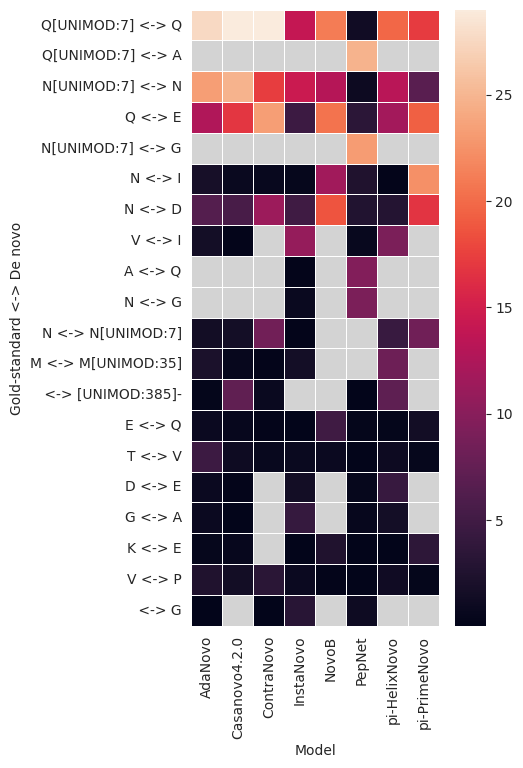

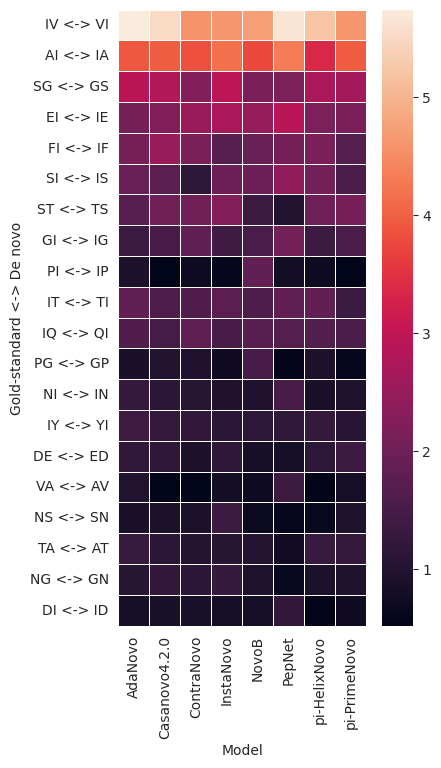

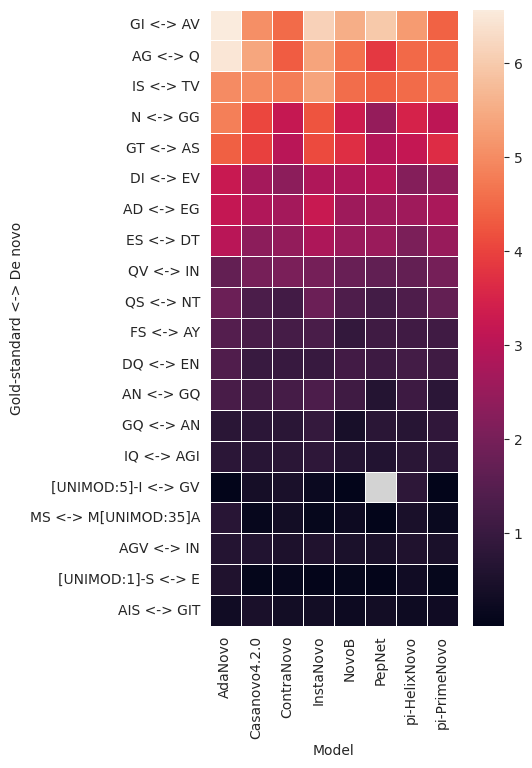

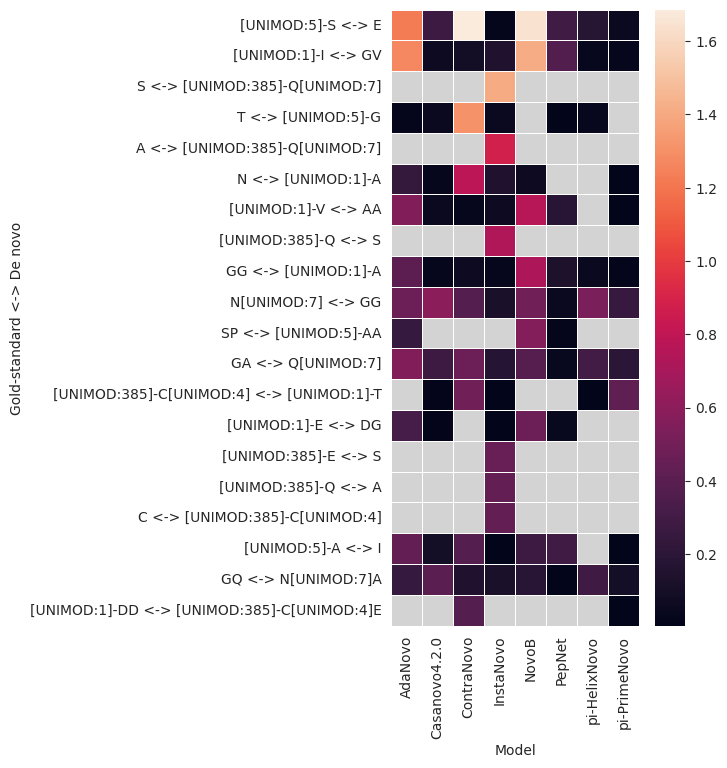

In [63]:
panels = {
    "A": ("SAAV",          'single_variants_melted',              'most_common_saav'),
    "B": ("Reorderings",   'transposition_reordering_selection',  'most_common_transpositions'),
    "C": ("isobaric",      'transposition_isobaric_selection',    'most_common_transpositions'),
    "D": ("alternative",   'transposition_alternative_selection', 'most_common_transpositions'),
}

matrices = {}
for letter, (key, sel, common) in panels.items():
    matrices[letter] = plot_variants_as_heatmap(
        error_type[key][sel],
        error_type[key][common],
        name=f"Suppl_variants_{letter}_{key}",
    )

with pd.ExcelWriter("Source_Data_Suppl_Variants.xlsx", engine="openpyxl") as xl:
    for letter, m in matrices.items():
        m.to_excel(xl, sheet_name=letter)

In [59]:
other_single_siters = df[
    (df['n_sites_merged']==1) &
    (df['levenshtein'] != 1) &
    (df['damerau-levenshtein'] >= 5)
]
other_single_siters_count = other_single_siters.groupby('model').count()['spectrum_id']

table_pct['large_single_site'] = (
    other_single_siters_count
    / df.groupby('model').count()['spectrum_id']
)*100

print('% of spectra with levenshtein distance != 1, single site, DL < 5')
print((
    other_single_siters_count
    / df.groupby('model').count()['spectrum_id']
)*100)

print('\nAverage %')
print((
    (other_single_siters_count / 
    df.groupby('model').count()['spectrum_id']).mean()
)*100)

% of spectra with levenshtein distance != 1, single site, DL < 5
model
AdaNovo          67.724483
Casanovo4.2.0    65.103754
ContraNovo       61.984594
InstaNovo        63.519845
NovoB            56.979081
PepNet           66.147154
pi-HelixNovo     66.506148
pi-PrimeNovo     56.344395
Name: spectrum_id, dtype: float64

Average %
63.03868176178331


In [61]:
other_variants, other_mds, indices = get_variants_per_model(
    df=other_single_siters,
    comparison_col='comparison_closest',
    model_col='model',
    model_names=denovo_engines,
    n_sites_col='n_sites_merged',
    annotations_col='annotations_merged'
)

other_alternative = pd.DataFrame(
    {model_name: v['alternative'] for model_name,v in other_variants.items()}
).reset_index(names='variant')
other_isobaric = pd.DataFrame(
    {model_name: v['isobaric_alternative'] for model_name,v in other_variants.items()}
).reset_index(names='variant')
other_reordering =pd.DataFrame(
    {model_name: v['reordering'] for model_name,v in other_variants.items()}
).reset_index(names='variant')

other_table_concat = pd.concat(
    [other_alternative, other_isobaric, other_reordering]
)

other_table = other_table_concat.set_index('variant') / other_table_concat.set_index('variant').sum()
other_table = other_table.reset_index().melt(
    id_vars='variant'
).sort_values('value', ascending=False)

most_common_others = other_table.drop_duplicates('variant')['variant'][:5]

In [88]:
table_pct['large_reorderings'] = (other_reordering.set_index('variant').sum() / 
        df.groupby('model').count()['spectrum_id']
    )*100

table_pct['large_isobaric'] = (other_isobaric.set_index('variant').sum() / 
        df.groupby('model').count()['spectrum_id']
    )*100
table_pct['large_alternative'] = (
        other_alternative.set_index('variant').sum() / 
        df.groupby('model').count()['spectrum_id']
    )*100


In [68]:
from itertools import chain

other_alternative_indices = list(chain(*[v['alternative'] for k, v in indices.items()]))
other_single_siters_alternatives = other_single_siters.loc[other_alternative_indices, :]

In [74]:
def tag_is_full_peptide(row):
    if row['psm_denovo'].peptidoform.modified_sequence in row['annotations_merged']['forward'][0][0]:
        return True
    for peptide_gt in row['comparison'].keys():
        if peptide_gt.replace('L', 'I').split('/')[0] in row['annotations_merged']['forward'][0][0]:
            return True
    return False

other_single_siters['completely_different'] = other_single_siters.apply(tag_is_full_peptide, axis=1)
other_single_siters_alternatives['completely_different'] = other_single_siters_alternatives.apply(tag_is_full_peptide, axis=1)

In [75]:
other_single_siters.completely_different.value_counts()

completely_different
False    365463
True     185943
Name: count, dtype: int64

In [100]:
table_pct['completely_different'] = (
    other_single_siters_alternatives[other_single_siters_alternatives['completely_different']].groupby('model').count()['spectrum_id'] / 
    df.groupby('model').count()['spectrum_id']
)*100

In [ ]:
table_pct['Partly different'] = (
    other_single_siters_alternatives[
        (other_single_siters_alternatives['completely_different']==False) &
        (other_single_siters_alternatives['L-norm'] >=.5)
    ].groupby('model').spectrum_id.count() / 
        df.groupby('model').count()['spectrum_id']
    )*100

In [109]:
table_pct_df = pd.DataFrame(table_pct).T

In [110]:
table_pct_df = table_pct_df.loc[
    [
        'SAAV',
        'transpositions',
        'transpositions_reordering',
        'transpositions_isobaric',
        'transpositions_alternative',
        'large_single_site',
        'large_reorderings',
        'large_isobaric',
        'completely_different',
        'Partly different'
    ],
    :
]

<Axes: xlabel='mds_annotation', ylabel='percentage'>

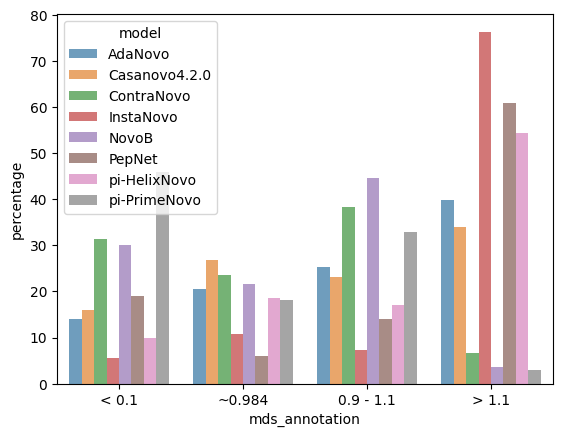

In [153]:
def annotate_mds(row):
    if row['mass_difference'] < .1:
        return '< 0.1'
    if (row['mass_difference'] > .983) and (row['mass_difference'] < .985):
        return '~0.984'
    if (row['mass_difference'] > .9) and (row['mass_difference'] < 1.1):
        return '0.9 - 1.1'
    if row['mass_difference'] > 1.1:
        return '> 1.1'


transposition_mds = error_type['mds']['transpositions']
transposition_alternative_selection = error_type['alternative']['transposition_alternative_selection']

groupby_mds = pd.DataFrame(
    {model_name: pd.Series(arr) for model_name, arr in transposition_mds.items()}
).melt().groupby('variable').value_counts()
groupby_mds.name = 'counts'
groupby_mds = groupby_mds.reset_index()
groupby_mds = groupby_mds.rename(columns={
    'variable': 'model',
    'value': 'mass_difference'
})


groupby_mds['mds_annotation'] = groupby_mds.apply(annotate_mds, axis=1)
groupby_mds = groupby_mds.groupby(['model', 'mds_annotation']).counts.sum().reset_index()
alternative_model_counts = transposition_alternative_selection.groupby('variable').value.sum().to_dict()
groupby_mds['percentage'] = groupby_mds.apply(
    lambda x: x['counts'] / alternative_model_counts[x['model']] *100,
    axis=1
)

sns.barplot(
    groupby_mds.sort_values('percentage', ascending=False),
    x='mds_annotation',
    hue='model',
    y='percentage',
    alpha=.7,
    hue_order=denovo_engines,
    order=['< 0.1', '~0.984', '0.9 - 1.1', '> 1.1']
)

In [116]:
table_pct_df.T.mean()

SAAV                           1.827576
transpositions                20.526542
transpositions_reordering      4.970186
transpositions_isobaric        6.728593
transpositions_alternative     8.827763
large_single_site             63.038682
large_reorderings              0.066446
large_isobaric                 5.983889
completely_different          20.045837
Partly different              36.942510
dtype: float64

In [156]:
table_pct_df

,AdaNovo,Casanovo4.2.0,ContraNovo,InstaNovo,NovoB,PepNet,pi-HelixNovo,pi-PrimeNovo
SAAV,0.865345,1.051325,1.611473,2.963386,0.769672,2.511958,0.898437,3.949008
transpositions,16.176072,17.236565,20.815193,19.195640,22.935879,23.678213,16.986925,27.187850
transpositions_reordering,4.108455,4.970528,5.994760,4.124654,6.728803,2.878720,4.035563,6.920006
transpositions_isobaric,5.490840,6.674193,8.045547,5.401081,8.896085,4.330519,6.022566,8.967914
transpositions_alternative,6.576778,5.591844,6.774886,9.669905,7.310991,16.468974,6.928795,11.299930
large_single_site,67.724483,65.103754,61.984594,63.519845,56.979081,66.147154,66.506148,56.344395
large_reorderings,0.036379,0.061184,0.094561,0.036042,0.104058,0.034509,0.059220,0.105617
large_isobaric,2.294171,3.387508,10.848880,1.727397,15.185331,3.060897,4.785949,6.580976
completely_different,24.778439,23.434215,21.670180,22.371764,12.454699,18.587686,22.196768,14.872943
Partly different,40.615494,38.220847,29.370974,39.384642,29.234992,44.464062,39.464211,34.784859


In [111]:
table_pct_df.sum() - table_pct_df.loc['transpositions'] - table_pct_df.loc['large_single_site']

AdaNovo          84.765900
Casanovo4.2.0    83.391645
ContraNovo       84.411261
InstaNovo        85.678871
NovoB            80.684632
PepNet           92.337325
pi-HelixNovo     84.391510
pi-PrimeNovo     87.481253
dtype: float64

In [113]:
table_pct_df.to_csv('Percentages_errors.csv')